In [1]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import re
import numpy as np

In [23]:
rows = []
erros = []

# Itera por cada profundidade
for depth in range(2):
    dir_ = f"../data/raw/expansao/{depth}/subreddits"
    if not os.path.exists(dir_):
        continue
    for filename in os.listdir(dir_):
        if filename.endswith(".json"):
            path = os.path.join(dir_, filename)
            try:
                with open(path, "r", encoding="utf-8") as f:
                    posts = json.load(f)
                # Adiciona a profundidade em cada post para rastreabilidade
                for post in posts:
                    post["depth"] = depth
                rows.extend(posts)
            except json.JSONDecodeError:
                erros.append(path)

print(f"Arquivos com erro: {len(erros)}")
print(f"Posts carregados: {len(rows)}")

df = pd.DataFrame(rows)
df.head()

Arquivos com erro: 0
Posts carregados: 2227113


,id,title,selftext,author,subreddit,score,timestamp,num_comments,url,is_self,over_18,removed_by_category,depth
0,1j3g0q5,Trudeau - ''I want to speak first directly to ...,NaN,RoyalChris,popculture,107449,2025-03-04T17:20:21+00:00,3736,https://reddit.com/r/popculture/comments/1j3g0...,False,False,NaN,0
1,1jdfbt3,Kim Kardashian endorses Nazi Elon Musk’s cyber...,S,wyokiddo,popculture,57062,2025-03-17T15:26:59+00:00,2743,https://reddit.com/r/popculture/comments/1jdfb...,False,False,NaN,0
2,1k7jcux,Candace Owens saying she no longer supports Do...,NaN,skyisscary,popculture,27509,2025-04-25T12:10:47+00:00,5419,https://reddit.com/r/popculture/comments/1k7jc...,False,False,NaN,0
3,1ilwij6,Kendrick Lamar called out for no white perform...,NaN,IrishStarUS,popculture,23908,2025-02-10T03:13:42+00:00,2525,https://reddit.com/r/popculture/comments/1ilwi...,False,False,NaN,0
4,1jfzx63,"Elon Musk's daughter, Vivian Wilson, stars in ...",NaN,RoyalChris,popculture,23502,2025-03-20T21:17:23+00:00,1152,https://reddit.com/r/popculture/comments/1jfzx...,False,False,NaN,0


In [24]:
print(f"Quantidade de subreddits únicos: {df['subreddit'].nunique()}")
print(f"Quantidade de autores únicos: {df['author'].nunique()}")
print(f"Quantidade de posts carregados: {len(df)}")

Quantidade de subreddits únicos: 7372


Quantidade de autores únicos: 1202164
Quantidade de posts carregados: 2227113


In [26]:
total_nulos = df['selftext'].isna().sum()
print(total_nulos)

1827562


---

#### 1. Análise dos subreddits

In [ ]:
x = df.groupby("subreddit").size().sort_values(ascending=False)
x.describe()

count    7372.000000
mean      302.104314
std        75.491840
min         1.000000
25%       298.000000
50%       299.000000
75%       299.000000
max       600.000000
dtype: float64

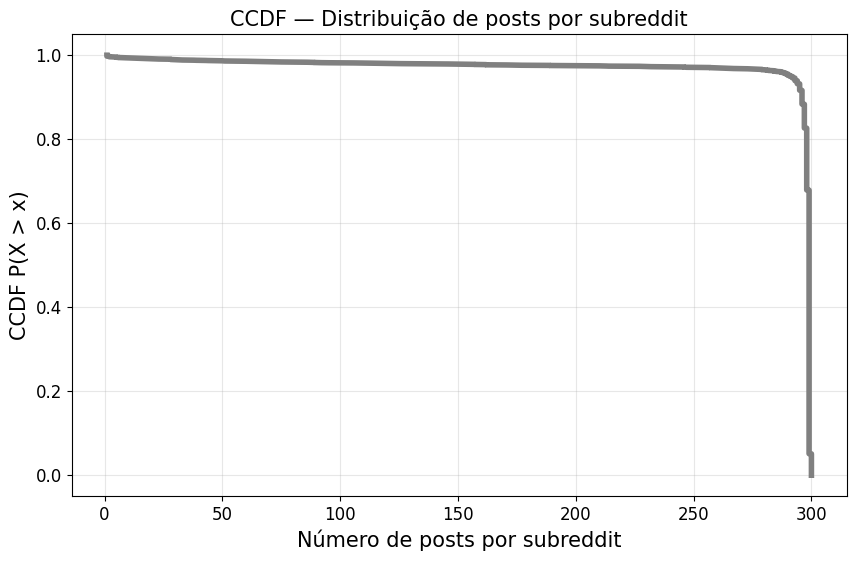

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Agrupamento e ordenação (permanecem iguais)
x = df.groupby("subreddit").size()
sorted_values = np.sort(x.values)

# 2. Cálculo da CCDF: P(X > x) é 1 - CDF
# Calculamos a proporção acumulada e subtraímos de 1
cdf = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
ccdf = 1 - cdf

plt.figure(figsize=(10, 6))

# 3. Plotagem da CCDF
plt.plot(sorted_values, ccdf, linewidth=4, color='gray')

plt.xlabel("Número de posts por subreddit", fontsize=15)
plt.ylabel("CCDF P(X > x)", fontsize=15)
plt.title("CCDF — Distribuição de posts por subreddit", fontsize=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

A grande maioria dos posts bateram no teto de 200 posts limitado no código, ou seja, foram alcançados subreddits ativos, com muitas postagens

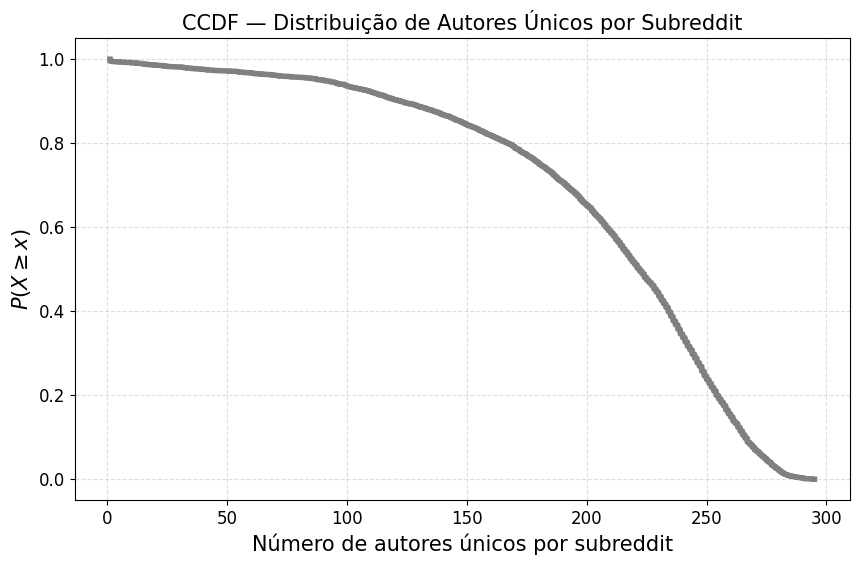

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculando o número de autores únicos por subreddit
# nunique() garante que cada usuário seja contado apenas uma vez por subreddit
autores_por_sub = df.groupby("subreddit")["author"].nunique()

# 2. Preparando os dados para a CCDF
sorted_values = np.sort(autores_por_sub.values)
n = len(sorted_values)
# P(X >= x)
ccdf = 1 - np.arange(1, n + 1) / n


plt.figure(figsize=(10, 6))
plt.plot(sorted_values, ccdf, linewidth=4, color='gray')
plt.xlabel("Número de autores únicos por subreddit", fontsize=15)
plt.ylabel(r"$P(X \geq x)$", fontsize=15)
plt.title("CCDF — Distribuição de Autores Únicos por Subreddit", fontsize=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()

Quando olhamos o números de usuários que plubicaram posts por subreddits, é possível ver uma distribuição maior, ou seja, é comum que tenham usuários mais ativos que publicam mais

---

#### 2. Análise dos usuários

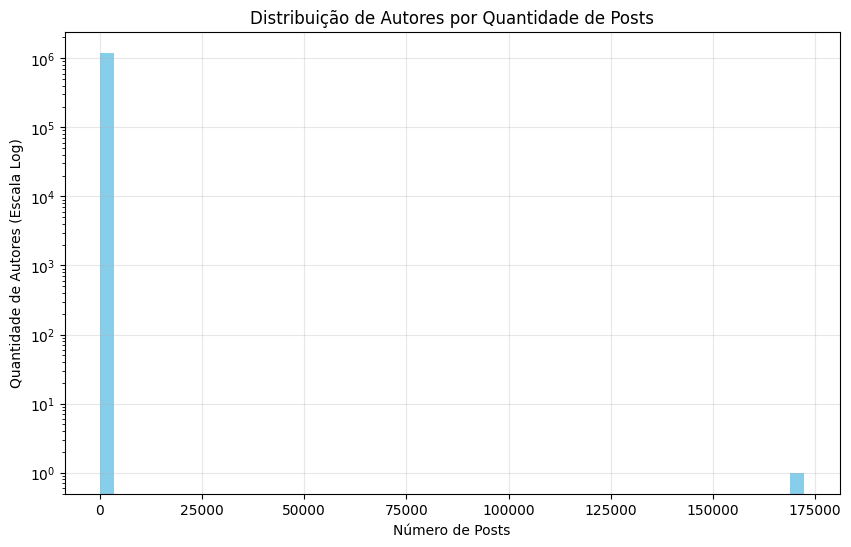

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

distintos_por_autor = df.groupby('author').size()

plt.figure(figsize=(10, 6))
plt.hist(distintos_por_autor, bins=50, color='skyblue')
plt.yscale('log')
plt.xlabel("Número de Posts")
plt.ylabel("Quantidade de Autores (Escala Log)")
plt.title("Distribuição de Autores por Quantidade de Posts")
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
distintos_por_autor.describe()

count    1.202164e+06
mean     1.852587e+00
std      1.572613e+02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      1.723700e+05
dtype: float64

A grande maioria nos autores fizeram apenas uma publicação, portanto, por mais que existam bastnates usuários mais ativos dentro dos subreddits, isso é feito por uma pequena comunidade de autores

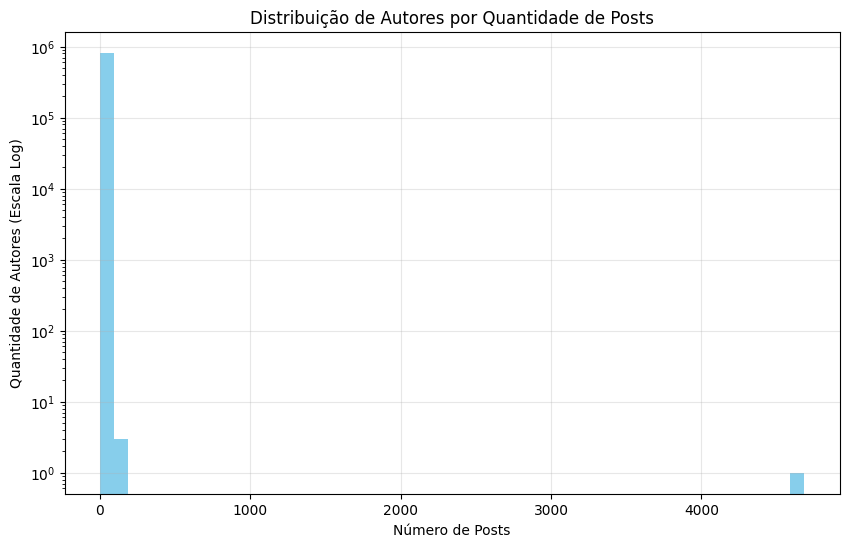

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

distintos_por_autor = df.groupby('author')['subreddit'].nunique()

plt.figure(figsize=(10, 6))
plt.hist(distintos_por_autor, bins=50, color='skyblue')
plt.yscale('log')
plt.xlabel("Número de Posts")
plt.ylabel("Quantidade de Autores (Escala Log)")
plt.title("Distribuição de Autores por Quantidade de Posts")
plt.grid(True, alpha=0.3)
plt.show()

Quando olhamos o número de subreddits que um autor publicou algo, este segue um comportamento parecido ao anterior, portanto, é de costume destes autores publicarem em mais de uma comunidade

---

### 3. Análise de engajamento

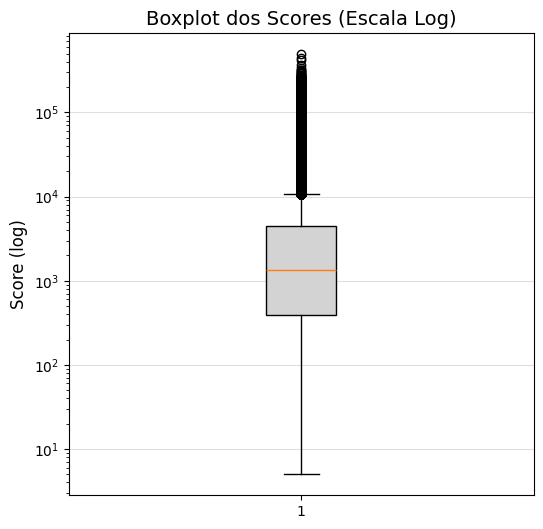

In [ ]:
plt.figure(figsize=(6, 6))
plt.boxplot(df['score'].dropna(), patch_artist=True, boxprops=dict(facecolor='lightgray'))

plt.yscale('log') 

plt.title("Boxplot dos Scores (Escala Log)", fontsize=14)
plt.ylabel("Score (log)", fontsize=12)
plt.grid(axis='y', alpha=0.4)
plt.show()

Grande parte dos posts tem 10 de score, mas existe uma boa quantidade com até 100, ao passar disso, se configuram os outliers, que não são poucos também, portanto, pode se dizer que a comunidade é engajada

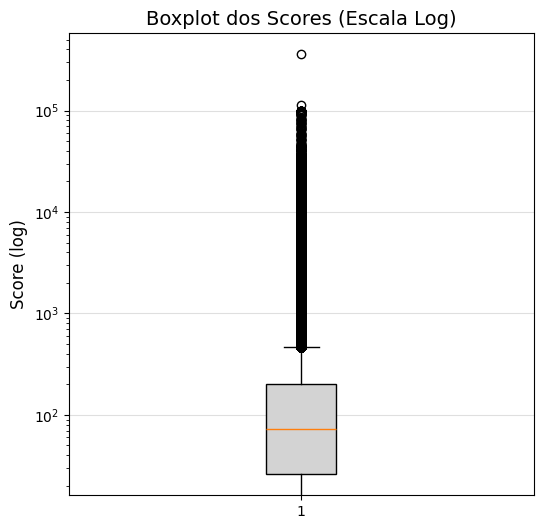

In [ ]:
plt.figure(figsize=(6, 6))
plt.boxplot(df['num_comments'].dropna(), patch_artist=True, boxprops=dict(facecolor='lightgray'))

plt.yscale('log') 

plt.title("Boxplot dos Scores (Escala Log)", fontsize=14)
plt.ylabel("Score (log)", fontsize=12)
plt.grid(axis='y', alpha=0.4)
plt.show()

É possível ver que os posts apresentam menos comentários em comparação aos scores, como o esperado, tendo em grande parte menos de 20 comentários, mas é possível que existem bastantes outliers que geraram um grande engajamento

---

### 4. Análise dos Títulos

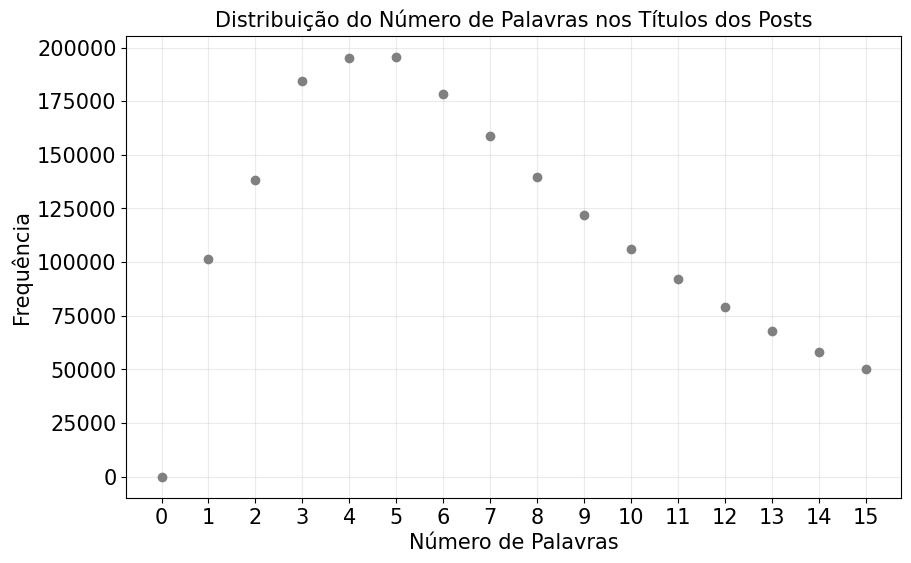

In [8]:
plt.figure(figsize=(10, 6))
x = df['title'].apply(lambda t: len(t.split()) if isinstance(t, str) else 0)

# Conta frequência de cada valor
counts = x.value_counts().sort_index()

# Filtra até 15 palavras
counts = counts[counts.index <= 15]

plt.plot(counts.index, counts.values, 'o', color='gray', markersize=6)
plt.title('Distribuição do Número de Palavras nos Títulos dos Posts', fontsize=15)
plt.xlabel('Número de Palavras', fontsize=15)
plt.ylabel('Frequência', fontsize=15)
plt.xticks(range(0, 16), fontsize=15)
plt.yticks(fontsize=15)
plt.grid(alpha=0.25)
plt.show()

In [14]:
KEYWORDS_RELEVANTES = [
    "manosphere", "men", "women", "gender", "violence", "misogyny", "online",
    "communities", "rights", "movement", "feminism", "masculinity", "power",
    "anti", "hate", "social", "media", "content", "groups", "male",
    "equality", "feminist", "harassment", "extremism", "ideology", "digital",
    "culture", "young", "boys", "influence", "forums", "internet",
    "relationships", "dating", "toxic", "narratives", "radicalization",
    "discrimination", "abuse", "identity", "politics", "patriarchy",
    "stereotypes", "control", "behavior", "attacks", "campaigns",
    "communities", "messages", "beliefs", "norms", "male", "dominance",
    "resentment", "hostility", "incels", "pickup", "artists", "redpill",
    "blackpill", "alpha", "beta", "victimhood", "women’s", "rights",
    "backlash", "agency", "representation", "harmful", "algorithms",
    "platforms", "audiences", "narrative", "language", "trends",
    "participation", "justice", "safety", "awareness", "education",
    "prevention", "research", "evidence", "discussion", "society",
    "communicate", "spaces", "moderation", "responses", "support",
    "change", "equity", "respect", "dialogue", "accountability"
]

def tem_keyword(title):
    if not isinstance(title, str):
        return False
    title_lower = title.lower()
    for kw in KEYWORDS_RELEVANTES:
        if kw in title_lower:
            return True
    return False

# 1. Aplica a função de keyword uma única vez no DataFrame original
df['relevante'] = df['title'].apply(tem_keyword)

# 2. Agrupa por depth e calcula as estatísticas de uma vez só
stats = df.groupby('depth')['relevante'].agg(['count', 'sum'])

# 3. Calcula as porcentagens
stats['% relevante'] = (stats['sum'] / stats['count']) * 100
stats['fora_do_tema'] = stats['count'] - stats['sum']
stats['% fora_do_tema'] = (stats['fora_do_tema'] / stats['count']) * 100

# 4. Exibe os resultados formatados
for d in stats.index:
    print(f"___________________________________________________")
    print(f"Total de posts (depth={d})      : {stats.loc[d, 'count']}")
    print(f"Posts relevantes (depth={d})    : {stats.loc[d, 'sum']} ({stats.loc[d, '% relevante']:.1f}%)")
    print(f"Posts fora do tema (depth={d})  : {stats.loc[d, 'fora_do_tema']} ({stats.loc[d, '% fora_do_tema']:.1f}%)")

___________________________________________________
Total de posts (depth=0)      : 294986
Posts relevantes (depth=0)    : 44410 (15.1%)
Posts fora do tema (depth=0)  : 250576 (84.9%)
___________________________________________________
Total de posts (depth=1)      : 1932127
Posts relevantes (depth=1)    : 182660 (9.5%)
Posts fora do tema (depth=1)  : 1749467 (90.5%)


---

## **Conclusão e limitações**

É possível ver que a quantidade de posts relevantes vai se perdendo ao longo da profundidade, ou seja, posts sobre outros assuntos vão sendo encontrados